<a href="https://colab.research.google.com/github/NickKar30/GM-HSE-AI-masters-course/blob/main/Hometasks/Base/GenDL_HT1_base.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнее задание - 1 (базовая группа)

В этом домашнем задании вы потренируетесь решать задачу speech-to-text.

Вы не будете тренировать сложную архитектуру с нуля, а попробуете решить эту задачу, пройдя по пайплайну, в котором задача разбита на несколько простых шагов.

- В этом задании мы призываем вас по-максимуму использовать документацию моделей и получить опыт написания кода без заготовок

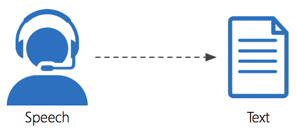

In [1]:
!pip install evaluate -q


[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: C:\Users\Tot\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


## Шаг 1 (1 балл)

* Возьмите датасет https://disk.yandex.ru/d/v2Hipv7XG4fEDQ, содержащий русскоязычные аудиозаписи

* Примените модель [whisper-small](https://huggingface.co/openai/whisper-small) из HF для определения сказанного в аудио.

* Выведите результат работы модели для 10 случайных аудио из датасета

Не стесняйтесь пользоваться документацией и источниками знаний из интернета!

In [1]:
# Load model directly
from transformers import AutoProcessor, AutoModelForSpeechSeq2Seq

processor = AutoProcessor.from_pretrained("openai/whisper-small")
model = AutoModelForSpeechSeq2Seq.from_pretrained("openai/whisper-small")

In [ ]:
pip install librosa

In [2]:
from transformers import WhisperForConditionalGeneration, WhisperProcessor
import json
import torch
import torchaudio
import requests
import io
import pandas as pd
if torch.cuda.is_available():
    device = "cuda"

In [3]:

model_name = "openai/whisper-small"
processor = WhisperProcessor.from_pretrained(model_name)
model = WhisperForConditionalGeneration.from_pretrained(model_name).to(device)
torch.cuda.empty_cache()

In [4]:


# пересэмплируйте имеющиеся аудио в 16 kHz - пример кода ниже, можете его менять
# if sr != 16000:
#     wav = torchaudio.functional.resample(wav, orig_freq=sr, new_freq=16000)
#     sr = 16000



def transcribe_url(url):
    try:
        response = requests.get(url)
        audio_file = io.BytesIO(response.content)
        # wav, sr = torchaudio.load(audio_file) почему то не сработал - выкидывал ошибку
        import librosa
        audio_file.seek(0)  
        wav_np, sr = librosa.load(audio_file, sr=16000)  
        wav = torch.tensor(wav_np).unsqueeze(0)  
        if sr != 16000:
            wav = torchaudio.functional.resample(wav, orig_freq=sr, new_freq=16000)

        input_features = processor(
            wav.squeeze().numpy(), 
            sampling_rate=16000, 
            return_tensors="pt"
        ).input_features.to(device) 
        
        forced_decoder_ids = processor.get_decoder_prompt_ids(language="russian", task="transcribe")
        
        predicted_ids = model.generate(
            input_features,
            language="russian",
            task="transcribe"
        )
        
        text = processor.batch_decode(predicted_ids, skip_special_tokens=True)[0]
        return text
        
    except Exception as e:
        print(f"Ошибка с {url}: {e}")
        return "ОШИБКА"

df = pd.read_csv("urls_normalized.tsv", sep='\t', header=None)

results = []
for url in df[0]:  
    
    text = transcribe_url(url)
    results.append(text)
    print(f'{text} : {url}')
df['transcription'] = results
df['transcription'].sample(10)



The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


 Жизнь других. : http://storage.mds.yandex.net:80/get-voicetoloka/1872575/197f271b-b23f-4ee0-b240-e956a172d7af
 Аутам Джон. : http://storage.mds.yandex.net:80/get-voicetoloka/1879367/3d8c8d43-f7f2-479b-a857-c90faa5e2faf
 Побег из Шаушенко. : http://storage.mds.yandex.net:80/get-voicetoloka/1872575/45161c4c-3f2c-4638-940e-a69404074ebb
 Дайон Уорвик : http://storage.mds.yandex.net:80/get-voicetoloka/1872575/3c0ebd62-2cc1-4c9c-be63-5733511a11cd
 Мохаммед Али : http://storage.mds.yandex.net:80/get-voicetoloka/2021744/6385560c-7068-45c2-9ba7-9e061249e0a4
 Дневник памяти. : http://storage.mds.yandex.net:80/get-voicetoloka/2021744/c4f3178c-14b2-44f8-b36e-f34a47520e10
 Ralf finds. : http://storage.mds.yandex.net:80/get-voicetoloka/1872575/0f2ef6c9-3dec-45ae-b456-8115c9419044
 Непть. : http://storage.mds.yandex.net:80/get-voicetoloka/1872575/4711cdac-8181-4f3c-8889-77cf408f3ff2
 Золотая лихорадка. : http://storage.mds.yandex.net:80/get-voicetoloka/2021744/37e917e1-1fdf-4064-a74f-57a84bcb28b9
 С

86                                    Старший сын
28                                Крестный отец 2
21                  Крошенинников Степан Петрович
24                              Однажды в Америке
44                   Барьмонт, Костянкин Дмитрий.
81                   Александр Владимирович Попов
31                                  Голова ломка.
90                                 Орета Франклин
69     Индиана Джонс и последний крестовый поход.
87                              Франциска Писсера
Name: transcription, dtype: object

In [5]:
# Показать полную ширину текста в ячейках
pd.set_option('display.max_colwidth', None)

In [6]:
df.sample(10, random_state=55)

,0,transcription
28,http://storage.mds.yandex.net:80/get-voicetoloka/1872575/373c13d2-0039-4ca1-a549-1563d2a8ef0a,Крестный отец 2
92,http://storage.mds.yandex.net:80/get-voicetoloka/1872575/c2338438-18b4-456a-b51f-d661f7473eac,Ганди.
98,http://storage.mds.yandex.net:80/get-voicetoloka/1879367/af0b23ef-7519-49e0-b32c-cab81f50f2f7,Крепкий орешек.
95,http://storage.mds.yandex.net:80/get-voicetoloka/2021744/00760e69-35b8-4c65-84f6-c1d0e82907c2,Помни!
84,http://storage.mds.yandex.net:80/get-voicetoloka/1872575/ca50a690-f1af-4a75-84e7-a8b121eff5e7,Джон Гудман
34,http://storage.mds.yandex.net:80/get-voicetoloka/1872575/d92c0f04-21ec-4578-98ec-d05602683126,Бобби Винтон
38,http://storage.mds.yandex.net:80/get-voicetoloka/1872575/871a6ddc-77b3-45e0-ab4d-2bdcddb78515,Звездной войны. Эпизод 5. Империя наносит ответный удар.
76,http://storage.mds.yandex.net:80/get-voicetoloka/1872575/1972e18d-dc62-418f-8a00-61f3235bbab9,Бред пит
17,http://storage.mds.yandex.net:80/get-voicetoloka/1879367/2a6d78d6-5b79-4ec1-bd9b-29b59c1960c1,Дай не трехо.
78,http://storage.mds.yandex.net:80/get-voicetoloka/1872575/f41d0849-5116-4900-b4c5-c9e201c30e06,400 ударов


Вроде более-менее. окончания только не особо верны. 

In [7]:
df_distr=df.copy()

## Шаг 2 (1 балл)

Текст распознается с ошибками.
Попробуйте исправить ошибки с помощью готовой (предобученной) модели spell correction.

Выведите на экран 10 текстов с предыдущего шага и их исправления с помощью модели https://huggingface.co/UrukHan/t5-russian-spell.

In [ ]:
pip install sentencepiece

In [8]:
from transformers import T5ForConditionalGeneration, T5Tokenizer

In [9]:
torch.cuda.empty_cache()
spell_model_name = "UrukHan/t5-russian-spell"
spell_tokenizer = T5Tokenizer.from_pretrained(spell_model_name)
spell_model = T5ForConditionalGeneration.from_pretrained(spell_model_name).to(device)


You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


In [10]:
from transformers import T5ForConditionalGeneration, T5Tokenizer
import torch

spell_model_name = "UrukHan/t5-russian-spell"
spell_tokenizer = T5Tokenizer.from_pretrained(spell_model_name)
spell_model = T5ForConditionalGeneration.from_pretrained(spell_model_name)

def correct_spelling(text):
    try:
        input_text = f"Spell correct: {text}"
        inputs = spell_tokenizer(input_text, padding=True, max_length=64, return_tensors='pt')
        
        with torch.no_grad():
            generated_ids = spell_model.generate(
                inputs=inputs['input_ids'],
                attention_mask=inputs['attention_mask'],
                max_length=64,
                num_beams=3,
                repetition_penalty=2.5,
                length_penalty=1.0,
                early_stopping=True
            )
        
        corrected_text = spell_tokenizer.decode(generated_ids[0], skip_special_tokens=True)
        return corrected_text
    except Exception as e:
        print(f"Ошибка при исправлении орфографии: {e}")
        return text

df['SP_correct_T5'] = df['transcription'].apply(correct_spelling)


c:\Users\Tot\AppData\Local\Programs\Python\Python313\Lib\site-packages\transformers\tokenization_utils_base.py:2779: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(


In [ ]:
transcription

In [11]:
df.sample(100)

,0,transcription,SP_correct_T5
94,http://storage.mds.yandex.net:80/get-voicetoloka/1872575/09c0c412-2316-4bf4-9f92-8349067de618,Брюс Springsteam,Брюс. ringsteam.
91,http://storage.mds.yandex.net:80/get-voicetoloka/2021744/86cae6ee-fe19-43b7-b6c7-cd30736167b1,Жан-поль-сартер,Жан-Поль-Сартер
56,http://storage.mds.yandex.net:80/get-voicetoloka/1879367/ce29f3d2-8c47-4466-a2b5-7bcb73b0eb02,двое,Двое.
93,http://storage.mds.yandex.net:80/get-voicetoloka/1872575/e3c3340d-2ac2-4c10-be96-8ee64b425d7b,На игре.,На игре.
36,http://storage.mds.yandex.net:80/get-voicetoloka/1872575/236b63a8-8f37-444d-8340-25324620e985,адвокат делала,Адвокат делала.
...,...,...,...
24,http://storage.mds.yandex.net:80/get-voicetoloka/1872575/d5bd3785-733a-4a95-b3ba-4d80ece002ee,Однажды в Америке,Однажды в Америке.
25,http://storage.mds.yandex.net:80/get-voicetoloka/2021744/0a1ff945-8476-4f17-a579-8780800592fd,Огни большого города.,Огни большого города.
90,http://storage.mds.yandex.net:80/get-voicetoloka/1879367/52f5c4dd-0c56-4e90-9f9b-162e2eab83f5,Орета Франклин,Орета Франклин
65,http://storage.mds.yandex.net:80/get-voicetoloka/1872575/b85b751d-b0b9-4b74-a62f-53b26a0d95ca,Ханс Хартун,Ханс Хартун


ну что то не особо помог, но в некоторых местах он исправил :
- Зег мунд фрейд : Зегмунд Фрейд  
- Служебный реман :	Служебный роман .  
В принципе у нас уже текст был хорошего качества..

## Шаг 3 (2 балла)

Соберите данные для дообучения модели выше. Для дообучения мы предлагаем вам использовать бесплатный api Groq: https://console.groq.com/docs/quickstart

Разберитесь с тем как пользоваться api (мы немного поможем вам с этим кодом ниже) и с его помощью соберите датасет (можно в несколько запросов).

- **0.5 балла** ставится за сбор датасета размером >1000 строк и сохранение в локальный файл/файлы

- **еще 0.5 балла** ставится за [создание huggingface dataset](https://huggingface.co/docs/datasets/create_dataset) (через использование библиотек datasets и huggingface) и [сохранение собранного датасета напрямую в HuggingFace](https://huggingface.co/docs/datasets/upload_dataset)

- **еще 1 балл** ставится за сбор датасета размером >1000 строк, на котором путем дообучения получится увеличить качество исправления опечаток в поставленной задаче (см. шаг 6) по сравнению с качеством прогноза той же, но предобученной модели

P.S. Если у Вас нет VPN, то можете воспользоваться другой LLM на Ваш выбор (можно, например, этим https://ollama.com/).

In [ ]:
# зайдите на страницу и создайте API KEY: https://console.groq.com/keys - возможно, понадобится включить VPN

import os

os.environ["GROQ_API_KEY"] = ***

In [ ]:
pip install groq

In [8]:
import os
from groq import Groq

client = Groq(api_key=os.environ.get("GROQ_API_KEY"))
# t_promt="""Сгенерируй,пожалуйста, 10 пар слов на русском языке.формата "верное слово" : "слово с опечаткой", пары разделены точкой, используй разнообразные опечатки, которые возможны при переводе из речи в текст, в том числе различные неверные окончания прилагательных, используй только кирилицу.
# """
t_promt="""
Создай, пожалуйста, 10 пар: слово и его вариант с опечаткой, как при распознавании речи.

Формат: правильное : ошибочное
Пример: корова : карова. привет : првиет. сегодня : сиводня.

Ошибки как при speech-to-text:
- фонетические замены (и/ы, о/а, с/ш)
- неправильные окончания
- пропуски согласных
- лишние гласные

формат "верное слово" : "слово с опечаткой". Разделитель межде парами - точка.
"""
response = client.chat.completions.create(
    messages=[{"role": "user", "content": t_promt}],
   model="llama-3.3-70b-versatile",
    # model="DeepSeek-R1-Distill-Llama-70B",
)

print(response.choices[0].message.content)

книга : кнίγа. 
стол : стіл. 
комната : каимата. 
привет : prvет. 
воздух : воидух. 
собака : собка. 
калибр : калибир. 
парк : паркi. 
птица : птїца. 
красота : красотаа.


In [ ]:

def gen_pairs_error_right(prompts):
#     prompts = """Сгенерируй,пожалуйста, 10 пар слов на русском языке.формата "верное слово" : "слово с опечаткой". пары разделены точкой.
# используй разнообразные опечатки, которые возможны при переводе из речи в текст, используй только киррилицу.
# """
    
    try:
        response = client.chat.completions.create(
            messages=[{"role": "user", "content": prompts}],
            model="llama-3.3-70b-versatile",
            temperature=0.8, 
            max_tokens=500
        )
        
        text = response.choices[0].message.content
        return text
    except Exception as e:
        print(f"Ошибка генерации: {e}")
        return None

In [46]:
def parse_word_pairs(text):
    pairs = {}
    segments = text.replace('/n', '').split('.') # на всякий убираю переводы на новую строку
    
    for seg in segments:
        seg = seg.strip()
        if ':' in seg:
            parts = seg.split(':', 1)
            if len(parts) == 2:
                cor_word = parts[0].strip()
                err_word = parts[1].strip()
                if (cor_word and err_word and 
                    cor_word != err_word and
                    len(cor_word) > 2):
                    pairs[err_word] = cor_word
    return pairs

In [32]:
import time

In [ ]:
def collect_dataset(target_size):
    dict2pd = {}
    
    while len(dict2pd) < target_size:
        text = gen_pairs_error_right(prompts = """Сгенерируй,пожалуйста, 10 пар слов на русском языке.формата "верное слово" : "слово с опечаткой". пары разделены точкой.
# используй разнообразные опечатки, которые возможны при переводе из речи в текст, используй только киррилицу.
# """)
        new_pairs = parse_word_pairs(text)
        dict2pd.update(new_pairs)
        
        print(f"Уникальных ошибок: {len(dict2pd)}/{target_size}")
        time.sleep(2)
    
    # Преобразуем в DataFrame
    df = pd.DataFrame([
        {'correct': correct, 'incorrect': error}
        for error, correct in dict2pd.items()
    ])
    
    return df

In [48]:
pd_pairs_cor_err=collect_dataset(target_size=50)

Уникальных ошибок: 10/50
Уникальных ошибок: 11/50
Уникальных ошибок: 20/50
Уникальных ошибок: 21/50
Уникальных ошибок: 28/50
Уникальных ошибок: 29/50
Уникальных ошибок: 38/50
Уникальных ошибок: 39/50
Уникальных ошибок: 40/50
Уникальных ошибок: 47/50
Уникальных ошибок: 53/50


In [49]:
pd_pairs_cor_err

,correct,incorrect
0,здесь,здесть
1,дом,доме
2,море,морее
3,стол,столл
4,лес,лесе
5,карандаш,карандашь
6,компьютер,компютер
7,телевизор,телевизер
8,автомобиль,автомобил
9,книга,книгга


тут нужна другая стратегия...

In [69]:
def generate_words():
    prompt = """
    Сгенерируй 50 распространенных русских слов (существительные, прилагательные, глаголы), которые чаще всего вречаются в речи.
    Только слова через запятую, без номеров и пояснений.
    Пример: привет, корова, здравствуйте, компьютер, автомобиль, красивый, интересный
    """
    
    try:
        response = client.chat.completions.create(
            messages=[{"role": "user", "content": prompt}],
            model="llama-3.3-70b-versatile", 
            temperature=0.6, # тут наверно надо поменьше чтоб набрать хотя бы 500 слов.
            max_tokens=500
        )
        text = response.choices[0].message.content
        words = [w.strip() for w in text.split(',') if w.strip()]
        return words
    except Exception as e:
        print(f"Ошибка: {e}")
        return []


In [70]:
def collect_words(number):

    correct_words = set()
    
    while len(correct_words) < number:
        new_words = generate_words()
        correct_words.update(new_words)
        print(f"Собрано слов: {len(correct_words)}/{number}")
        time.sleep(3)
    
    return list(correct_words)[:number]


In [71]:
r=collect_words(1000)

Собрано слов: 47/1000
Собрано слов: 77/1000
Собрано слов: 129/1000
Собрано слов: 159/1000
Собрано слов: 172/1000
Собрано слов: 267/1000
Собрано слов: 286/1000
Собрано слов: 303/1000
Собрано слов: 309/1000
Собрано слов: 330/1000
Собрано слов: 354/1000
Собрано слов: 365/1000
Собрано слов: 375/1000
Собрано слов: 465/1000
Собрано слов: 471/1000
Собрано слов: 487/1000
Собрано слов: 509/1000
Собрано слов: 522/1000
Собрано слов: 540/1000
Собрано слов: 599/1000
Собрано слов: 607/1000
Собрано слов: 614/1000
Собрано слов: 623/1000
Собрано слов: 629/1000
Собрано слов: 631/1000
Собрано слов: 637/1000
Собрано слов: 669/1000
Собрано слов: 671/1000
Собрано слов: 687/1000
Собрано слов: 692/1000
Собрано слов: 701/1000
Собрано слов: 707/1000
Собрано слов: 721/1000
Собрано слов: 755/1000
Собрано слов: 804/1000
Собрано слов: 808/1000
Собрано слов: 822/1000
Собрано слов: 826/1000
Собрано слов: 839/1000
Собрано слов: 839/1000
Собрано слов: 842/1000
Собрано слов: 847/1000
Собрано слов: 854/1000
Собрано слов:

In [72]:
r

['низко.',
 'орден',
 'грустный',
 'пример',
 'народ',
 'апельсин',
 'разум',
 'успешный',
 'эмоция',
 'низко',
 'пока',
 'инновация',
 'терапия',
 'час',
 'образование',
 'болезнь',
 'общество',
 'скорость',
 'достоинство',
 'сегодня',
 'дорога',
 'мужество',
 'тонкость',
 'креативность',
 'есть',
 'огонь',
 'взаимопонимание',
 'ложь',
 'журнал',
 'уважение',
 'теория',
 'радуга',
 'вернусь',
 'экономика',
 'деревья',
 'восхищение',
 'работает',
 'сплю',
 'автор',
 'глубина',
 'отпуск',
 'достигать',
 'спать',
 'далеко',
 'возможность',
 'мотивация',
 'папа',
 'старый',
 'бизнес',
 'прощать',
 'лежу',
 'комфорт',
 'стойкость',
 'еда',
 'слушать',
 'небо',
 'шарф',
 'онтология',
 'корабль',
 'легко',
 'отдых',
 'звонить',
 'может быть',
 'рождение',
 'надежда',
 'животные',
 'студент',
 'слеза',
 'гостиная',
 'мать',
 '云',
 'романтизм',
 'ветер',
 'самосознание',
 'литература',
 'дружелюбный',
 'океан',
 'душа',
 'заботливость',
 'оценка',
 'маленький',
 'разрабатывать',
 'компания',
 

In [80]:
import re

In [84]:
words = {re.sub(r'[^а-яё]', '', word.replace(".", "")) for word in r if re.sub(r'[^а-яё]', '', word.replace(".", ""))}


In [85]:
len(words)

983

In [86]:
words

{'ав',
 'авиарейс',
 'автобус',
 'автомобиль',
 'автор',
 'авторитет',
 'аккуратность',
 'аксиология',
 'актер',
 'активный',
 'алгоритмы',
 'алчность',
 'анализ',
 'антропология',
 'апельсин',
 'архитектура',
 'ать',
 'аэропорт',
 'бабушка',
 'баланс',
 'балет',
 'банки',
 'баскетбол',
 'бегает',
 'бегать',
 'бегу',
 'бедность',
 'бедный',
 'бежать',
 'безопасность',
 'бережность',
 'библиотека',
 'бизнес',
 'биология',
 'благодарить',
 'благодарность',
 'благополучие',
 'блаженство',
 'близко',
 'богатство',
 'богатый',
 'болезнь',
 'боль',
 'больница',
 'больной',
 'большой',
 'борьба',
 'брат',
 'братство',
 'брать',
 'братья',
 'будет',
 'буду',
 'будущее',
 'бумага',
 'быстро',
 'быстрый',
 'быть',
 'ванная',
 'вдохновение',
 'вдохновлять',
 'велосипед',
 'вера',
 'верить',
 'верность',
 'вернусь',
 'верю',
 'веселиться',
 'веселый',
 'веселье',
 'весна',
 'ветер',
 'вечер',
 'взаимопонимание',
 'видение',
 'видеть',
 'видит',
 'вкусная',
 'вкусный',
 'влияние',
 'вмагазине',
 'в

In [109]:
def gen_errors(word, num_errors=3):
    prompt = f"""
    Для слова "{word}" придумай {num_errors} варианта с опечатками, как при распознавании речи.
    
    Формат:ошибка1, ошибка2, ошибка3.
    
    Типы ошибок:
    о/а, и/е, с/ш, з/с, в/ф, г/х, д/т, б/п, ж/ш, ц/с, ч/щ, ы/и, э/е, ю/у, я/а
    пропуски согласных, пропуски гласных, лишние согласные, лишние гласные
    неправильные падежи, неправильные окончания, слитное написание, раздельное написание
    замены мягких/твердых, оглушение согласных, озвончение согласных
    перестановки букв, повторения слогов, потеря окончаний
    """
    
    try:
        response = client.chat.completions.create(
            messages=[{"role": "user", "content": prompt}],
            model="meta-llama/llama-4-maverick-17b-128e-instruct",
            # model="llama-3.3-70b-versatile", #закончился лимит =-(
            temperature=0.9,
            max_tokens=200
        )
        return response.choices[0].message.content
    except Exception as e:
        print(f"Ошибка для слова {word}: {e}")
        return ""


In [110]:
big_dict={}

In [101]:
from tqdm import tqdm

for word in tqdm(words, desc="Генерация ошибок"):
    keys = gen_errors(word=word).replace('/n', '').replace('.', '').split(',')
    big_dict.update({key.strip(): word for key in keys if key.strip() != word})
    time.sleep(2)

Генерация ошибок:  29%|██▉       | 288/983 [11:06<27:29,  2.37s/it]

Ошибка для слова центр: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01k7bz8kzjftwtkdw9c64505mb` service tier `on_demand` on tokens per day (TPD): Limit 100000, Used 100047, Requested 244. Please try again in 4m11.902s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}


Генерация ошибок:  29%|██▉       | 289/983 [11:08<26:33,  2.30s/it]

Ошибка для слова зависимость: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01k7bz8kzjftwtkdw9c64505mb` service tier `on_demand` on tokens per day (TPD): Limit 100000, Used 100045, Requested 245. Please try again in 4m10.652s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}


Генерация ошибок:  30%|██▉       | 290/983 [11:10<25:52,  2.24s/it]

...

Ошибка для слова слушаю: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01k7bz8kzjftwtkdw9c64505mb` service tier `on_demand` on tokens per day (TPD): Limit 100000, Used 100025, Requested 245. Please try again in 3m53.742s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}


Генерация ошибок:  30%|███       | 298/983 [11:27<24:12,  2.12s/it]

Ошибка для слова улица: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01k7bz8kzjftwtkdw9c64505mb` service tier `on_demand` on tokens per day (TPD): Limit 100000, Used 100023, Requested 245. Please try again in 3m51.625s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}


Генерация ошибок:  30%|███       | 298/983 [11:29<26:25,  2.31s/it]


KeyboardInterrupt: 

In [112]:
big_dict

{'наплеже': 'напляже',
 'на пляже': 'напляже',
 'напляжэ': 'напляже',
 'науука': 'наука',
 'наукуа': 'наука',
 'тедя': 'тетя',
 'тея': 'тетя',
 'тетяя': 'тетя',
 'утроо': 'утро',
 'утры': 'утро',
 'утрэ': 'утро',
 'комнтата': 'комната',
 'камната': 'комната',
 'команata': 'комната',
 'Хорошо': 'хороший',
 'харашо': 'хорошо',
 'харашоо': 'хорошо',
 'вооброжение': 'воображение',
 'вабражиние': 'воображение',
 'ваображение': 'воображение',
 'цент': 'центр',
 'сенцтр': 'центр',
 'цэнтр': 'центр',
 'зависимось': 'зависимость',
 'зависемость': 'зависимость',
 'зависымость': 'зависимость',
 'тяжолый': 'тяжелый',
 'тижелый': 'тяжелый',
 'тжелый': 'тяжелый',
 'наследие: на следие': 'наследие',
 'насладие': 'наследие',
 'наследее': 'наследие',
 'здгавствуйте': 'здравствуйте',
 'здавстуйте': 'здравствуйте',
 'сдравствуйте': 'здравствуйте',
 'страах': 'страх',
 'сстрах': 'страх',
 'весилиться': 'веселиться',
 'виселится': 'веселиться',
 'веселлиться': 'веселиться',
 'гаварю': 'говорю',
 'гаворю': 

In [103]:
big_dict_new = {key: value for key, value in big_dict.items() if len(key.split()) == 1}

In [114]:
len(big_dict_new)

680

In [ ]:
already_gen_words=set(big_dict.values())

In [111]:
from tqdm import tqdm

for word in tqdm(words-set(big_dict_new.values()), desc="Генерация ошибок"): # уберем что уже сгенерировалось
    keys = gen_errors(word=word).replace('/n', '').replace('.', '').split(',')
    big_dict.update({key.strip(): word for key in keys if key.strip() != word})
    time.sleep(2)

Генерация ошибок: 100%|██████████| 701/701 [26:31<00:00,  2.27s/it]


In [115]:
big_full_dict={}
big_full_dict.update(big_dict_new)
big_full_dict.update(big_dict)

In [116]:
len(big_full_dict)

2694

In [120]:
big_full_dict = {key: value for key, value in big_full_dict.items() if len(key.split()) == 1}

In [121]:
len(big_full_dict)

2572

In [122]:
with open('big_full_dict.json', 'w', encoding='utf-8') as f:
    json.dump(big_full_dict, f, ensure_ascii=False, indent=2)

In [ ]:
pip install datasets huggingface_hub

In [12]:
with open('big_full_dict.json', 'r', encoding='utf-8') as f:
    big_full_dict = json.load(f)

In [13]:
big_full_dict

{'ореден': 'орден',
 'арден': 'орден',
 'орденъ': 'орден',
 'гурстный': 'грустный',
 'грустней': 'грустный',
 'прмимер': 'пример',
 'примэр': 'пример',
 'нарэд': 'народ',
 'народъ': 'народ',
 'апалсин': 'апельсин',
 'апельсинь': 'апельсин',
 'Разум': 'разум',
 'рахум': 'разум',
 'рузум': 'разум',
 'успешнии': 'успешный',
 'эмция': 'эмоция',
 'эмоція': 'эмоция',
 'низок': 'низко',
 'нызко': 'низко',
 'поки': 'пока',
 'пака': 'пока',
 'инноваций': 'инновация',
 'инновація': 'инновация',
 'инновацыя': 'инновация',
 'терапеия': 'терапия',
 'терапияя': 'терапия',
 'шас': 'час',
 'оброжение': 'образование',
 'образовфние': 'образование',
 'оброзование': 'образование',
 'белезнь': 'болезнь',
 'болезнк': 'болезнь',
 'болезън': 'болезнь',
 'обшество': 'общество',
 'общества': 'общество',
 'общесвто': 'общество',
 'скорось': 'скорость',
 'скоросф': 'скорость',
 'скоростьь': 'скорость',
 'достоинсво': 'достоинство',
 'сеодня': 'сегодня',
 'седня': 'сегодня',
 'сегоця': 'сегодня',
 'дорага': 'доро

In [17]:
from datasets import Dataset, DatasetDict
from huggingface_hub import login, HfApi



login(token="***")


# dataset = Dataset.from_dict(big_full_dict)
api = HfApi()
api.upload_file(
    path_or_fileobj="big_full_dict.json",  
    path_in_repo="big_full_dict.json",
    repo_id="Alexxxtot/4_hw1", 
    repo_type="dataset"
)
# 
# dataset.push_to_hub("Alexxxtot/4_hw1")

CommitInfo(commit_url='https://huggingface.co/datasets/Alexxxtot/4_hw1/commit/6d4cd602b8db20547024dd366dc419ca4093ff22', commit_message='Upload big_full_dict.json with huggingface_hub', commit_description='', oid='6d4cd602b8db20547024dd366dc419ca4093ff22', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/Alexxxtot/4_hw1', endpoint='https://huggingface.co', repo_type='dataset', repo_id='Alexxxtot/4_hw1'), pr_revision=None, pr_num=None)

ссылка на словарь
https://huggingface.co/datasets/Alexxxtot/4_hw1/resolve/main/big_full_dict.json?download=true

## Шаг 4 (2 балла)

Дообучите модель выше или любую другую модель, которая вам нравится, на собранных данных и протестируйте ее на нескольких ошибочно распознанных whisper-small моделью аудио. Дообучение мы разбирали на семинаре - можете посмотреть, как мы это делали там.

Для оценки качества результата выведите на экран 10 текстов с предыдущего шага и их исправления с помощью модели.

- Вы можете воспользовать структурой, предложенной в ячейке ниже, а можете написать код по-своему.

In [ ]:
pip install --upgrade transformers datasets

In [ ]:
pip install transformers[torch]

In [7]:
pip install accelerate>=0.26.0

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
import os
os.environ["WANDB_DISABLED"] = "true"

In [15]:
import torch
from datasets import Dataset, load_dataset
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, DataCollatorForSeq2Seq, Seq2SeqTrainer, Seq2SeqTrainingArguments
import pandas as pd
with open('big_full_dict.json', 'r', encoding='utf-8') as f:
    big_full_dict = json.load(f)
# Загружаем модель и токенизатор
model_name = "UrukHan/t5-russian-spell"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(device)

df_add = pd.DataFrame([
    {"error": error, "correct": correct} 
    for error, correct in big_full_dict.items()
])

def prepare_dataset(df):
    dataset = []
    for _, row in df.iterrows():
        dataset.append({
            "input_text": f"Spell correct: {row['error']}",
            "target_text": row['correct']
        })
    return Dataset.from_list(dataset)

dataset = prepare_dataset(df_add)


def tokenize_function(examples):
    inputs = tokenizer(
        examples["input_text"],
        max_length=64,
        padding="max_length",
        truncation=True
    )
    
    with tokenizer.as_target_tokenizer():
        targets = tokenizer(
            examples["target_text"],
            max_length=64,
            padding="max_length",
            truncation=True
        )
    
    inputs["labels"] = targets["input_ids"]
    return inputs

tokenized_dataset = dataset.map(tokenize_function, batched=True)

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding=True
)

training_args = Seq2SeqTrainingArguments(
    output_dir="./spell_correction_finetuned",
    overwrite_output_dir=True,
    num_train_epochs=3,
    per_device_train_batch_size=16,  
    per_device_eval_batch_size=16,  
    warmup_steps=100,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=50,
    save_steps=500,
    save_total_limit=2,
    # evaluation_strategy="no",
    predict_with_generate=True,
    learning_rate=5e-5,
    dataloader_pin_memory=True,     
    fp16=True,                  
    report_to=None
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset,
    data_collator=data_collator,
    tokenizer=tokenizer,
)

print("Старт дообучения...")
trainer.train()


trainer.save_model("./spell_correction_finetuned")
tokenizer.save_pretrained("./spell_correction_finetuned")
print("Модель дообучена и сохранена!")

Map:   0%|          | 0/2572 [00:00<?, ? examples/s]

c:\Users\Tot\AppData\Local\Programs\Python\Python313\Lib\site-packages\transformers\tokenization_utils_base.py:4034: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
C:\Users\Tot\AppData\Local\Temp\ipykernel_17184\3841277289.py:76: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


Старт дообучения...


Step,Training Loss
50,7.160600
100,0.070900
150,0.048600
200,0.034800
250,0.031200
300,0.031400
350,0.025600
400,0.020900
450,0.021800


c:\Users\Tot\AppData\Local\Programs\Python\Python313\Lib\site-packages\transformers\modeling_utils.py:3922: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 256}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(


Модель дообучена и сохранена!


Примените дообученную модель. Как раз здесь для оценки качества результата выведите на экран 10 текстов с предыдущего шага и их исправления с помощью модели.

In [16]:
df.sample(20)

,0,transcription,SP_correct_T5
83,http://storage.mds.yandex.net:80/get-voicetoloka/2021744/38e898d9-0707-4b1f-a01a-c2da05315be6,Ходячий замок,Ходячий замок.
53,http://storage.mds.yandex.net:80/get-voicetoloka/1879367/56280403-d892-44fb-864a-81fb2943c77c,Гроздь я к Неву.,Гроздь я к Неву.
70,http://storage.mds.yandex.net:80/get-voicetoloka/2021744/533e00e4-0e05-4319-b82e-411ab57b8802,Бейб Дидриксон Захарис,Бейб Дидриксон Захарис
45,http://storage.mds.yandex.net:80/get-voicetoloka/1879367/ed3f4cd7-801b-4d3c-a237-a9d662d04fd5,Feel callings.,Feel callings.
44,http://storage.mds.yandex.net:80/get-voicetoloka/1872575/537c7e5c-fda8-46f2-8395-4420dd34dec5,"Барьмонт, Костянкин Дмитрий.","Барьмонт, Костянкин, Дмитрий"
39,http://storage.mds.yandex.net:80/get-voicetoloka/2021744/2b9c598f-c08f-43eb-ac28-72cf962a9a05,Ирония судьбы или с лёгким паром,Ирония судьбы или с лёгким паром.
22,http://storage.mds.yandex.net:80/get-voicetoloka/1872575/df8e6c78-0227-435c-92d0-b884bd61c91f,Шон Бин,Шон Бин
80,http://storage.mds.yandex.net:80/get-voicetoloka/1879367/2144ca43-13e4-49ad-9c8e-5a5ecf8599d9,Распутин Валентин Григорьевич,Распутин Валентин Григорьевич
10,http://storage.mds.yandex.net:80/get-voicetoloka/1872575/c53908cc-adb1-418b-b68b-f67094fc4afd,Брайан Адамс,Брайан Адамс
0,http://storage.mds.yandex.net:80/get-voicetoloka/1872575/197f271b-b23f-4ee0-b240-e956a172d7af,Жизнь других.,Жизнь других.


In [17]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# Загружаем дообученную модель
model_path = "./spell_correction_finetuned"
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSeq2SeqLM.from_pretrained(model_path).to(device)

# Применение модели к 10 примерам
def correct_with_finetuned(text):
    """Исправляет текст с помощью дообученной модели"""
    if text == "ОШИБКА" or not text.strip():
        return text
    
    input_text = f"Spell correct: {text}"
    inputs = tokenizer(input_text, return_tensors="pt", max_length=128, truncation=True).to(device)
    
    with torch.no_grad():
        outputs = model.generate(
            inputs.input_ids,
            max_length=64,
            num_beams=3,
            early_stopping=True
        )
    
    corrected = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return corrected

# Добавляем столбец с исправлениями от дообученной модели
df['finetuned_correction'] = df['transcription'].apply(correct_with_finetuned)
df.sample(20)

,0,transcription,SP_correct_T5,finetuned_correction
79,http://storage.mds.yandex.net:80/get-voicetoloka/1872575/4c0f8f80-99f2-4dba-b54f-1860e07af180,"Гарри Поттер и дары смерти, части два.",Гарри Поттер и Дары Смерти. Часть 2.,"Гарри Поттер и дары смерти, часть 2"
37,http://storage.mds.yandex.net:80/get-voicetoloka/1872575/ba9e8621-7c94-46aa-93de-abb816732da7,Отступники.,Отступники.,преступник
65,http://storage.mds.yandex.net:80/get-voicetoloka/1872575/b85b751d-b0b9-4b74-a62f-53b26a0d95ca,Ханс Хартун,Ханс Хартун,Ханс Хартун
54,http://storage.mds.yandex.net:80/get-voicetoloka/1872575/84c7ed3f-4010-4de2-8a30-88a312be0bba,Смоки Робинсон,Смоки Робинсон,Стивен Робинсон
15,http://storage.mds.yandex.net:80/get-voicetoloka/2021744/969c8460-29a8-4c6a-ac71-bc729a6d1f3d,Криминальная чтива.,Криминальная книга.,криминальная репутация
20,http://storage.mds.yandex.net:80/get-voicetoloka/1879367/c5a115d7-015f-421c-94ce-ed9928151491,Аристотель.,Аристотель.,архитектор
99,http://storage.mds.yandex.net:80/get-voicetoloka/1872575/f9d9fa24-0e3c-430f-8e42-622a0fa0c6a5,Кейт Буш.,Кейт Буш.,Кейт Буш
25,http://storage.mds.yandex.net:80/get-voicetoloka/2021744/0a1ff945-8476-4f17-a579-8780800592fd,Огни большого города.,Огни большого города.,огни большого города
56,http://storage.mds.yandex.net:80/get-voicetoloka/1879367/ce29f3d2-8c47-4466-a2b5-7bcb73b0eb02,двое,Двое.,двое
17,http://storage.mds.yandex.net:80/get-voicetoloka/1879367/2a6d78d6-5b79-4ec1-bd9b-29b59c1960c1,Дай не трехо.,Дай не трех.,дай мне три


## Шаг 5 (1 балл)

Время считать метрики и возвращаться к дообучению модели по необходимости. В этом шаге мы оцениваем только выполнение задания, а не значения метрик.

a) [Здесь](https://disk.yandex.ru/d/SPJU3lCt_cMDcw) лежат правильные ответы почти на все аудио - считайте метрики только для аудио, для которых мы дали вам ответы. Посчитайте [WER](https://docs.pytorch.org/torcheval/main/generated/torcheval.metrics.WordErrorRate.html) для модели whisper-small.

б) Посчитайте WER для whisper-small + исправление опечаток предобученной моделью (модель выберите самостоятельно!)

в) Посчитайте WER для whisper-small + дообученная Вами модель (данные для дообучения и модель выберите самостоятельно!)

In [25]:
pip install torcheval

[notice] A new release of pip is available: 25.0.1 -> 25.2

[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [67]:
import json
import pandas as pd
import torch
from torcheval.metrics import WordErrorRate
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

with open('result_array.json', 'r', encoding='utf-8') as f:
    data = json.load(f)
dict_true = {item['url']: item['text'] for item in data}
device = "cuda" 

model_path = "./spell_correction_finetuned"
tokenizer = AutoTokenizer.from_pretrained(model_path)
finetuned_model = AutoModelForSeq2SeqLM.from_pretrained(model_path).to(device)

def correct_with_finetuned(text):
    input_text = f"Spell correct: {text}"
    inputs = tokenizer(input_text, return_tensors="pt", max_length=128, truncation=True).to(device)
    with torch.no_grad():
        outputs = finetuned_model.generate(
            inputs.input_ids,
            max_length=128,
            num_beams=3,
            early_stopping=True
        )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

original_model_path = "UrukHan/t5-russian-spell"
original_tokenizer = AutoTokenizer.from_pretrained(original_model_path)
original_model = AutoModelForSeq2SeqLM.from_pretrained(original_model_path).to(device)

def correct_with_original(text):
    input_text = f"Spell correct: {text}"
    inputs = original_tokenizer(input_text, return_tensors="pt", max_length=128, truncation=True).to(device)
    with torch.no_grad():
        outputs = original_model.generate(
            inputs.input_ids,
            max_length=128,
            num_beams=3,
            early_stopping=True
        )
    return original_tokenizer.decode(outputs[0], skip_special_tokens=True)

results = []
for url, correct_text in dict_true.items():
    matching_rows = df[df[0] == url]
    
    if not matching_rows.empty:
        whisper_text = matching_rows.iloc[0]['transcription']
        t5_corrected = matching_rows.iloc[0]['SP_correct_T5']
        finetuned_corrected = correct_with_finetuned(whisper_text)
        results.append({
            'url': url,
            'verno': correct_text,
            'whisper': whisper_text,
            't5_corrected': t5_corrected,
            'finetuned_corrected': finetuned_corrected
        })

res_df = pd.DataFrame(results)
wm_whisper = WordErrorRate()
wm_t5 = WordErrorRate() 
wm_finetuned = WordErrorRate()

for _, row in res_df.iterrows(): 
    gt_normalized = row['verno'].lower().strip()
    whisper_normalized = row['whisper'].lower().strip()
    t5_normalized = row['t5_corrected'].lower().strip()
    finetuned_normalized = row['finetuned_corrected'].lower().strip()
    
    wm_whisper.update(whisper_normalized, gt_normalized)
    wm_t5.update(t5_normalized, gt_normalized)
    wm_finetuned.update(finetuned_normalized, gt_normalized)

wer_whisper = wm_whisper.compute().item()
wer_t5 = wm_t5.compute().item()
wer_finetuned = wm_finetuned.compute().item()

wer_table = pd.DataFrame({
    'Модель': [
        'original', 
        'original + T5', 
        'original + дообученная'
    ],
    'WER': [wer_whisper, wer_t5, wer_finetuned]
})
wer_table


,Модель,WER
0,original,0.495652
1,original + T5,0.521739
2,original + дообученная,0.465217


In [36]:
print(f"Всего {len(res_df)}")

Всего 96


In [69]:
res_df.sample(10)

,url,verno,whisper,t5_corrected,finetuned_corrected
30,http://storage.mds.yandex.net:80/get-voicetoloka/1872575/86aaebac-a43a-4f80-a6e4-136bfb5492e3,головоломка,Голова ломка.,Голова ломка.,голова ломкая
77,http://storage.mds.yandex.net:80/get-voicetoloka/1879367/2144ca43-13e4-49ad-9c8e-5a5ecf8599d9,распутин валентин григорьевич,Распутин Валентин Григорьевич,Распутин Валентин Григорьевич,Распутин Валентин Григорьевич
5,http://storage.mds.yandex.net:80/get-voicetoloka/1872575/0f2ef6c9-3dec-45ae-b456-8115c9419044,рэйф файнс,Ralf finds.,Ralf Finds.,Ralf finds
76,http://storage.mds.yandex.net:80/get-voicetoloka/1872575/4c0f8f80-99f2-4dba-b54f-1860e07af180,гарри поттер и дары смерти часть два,"Гарри Поттер и дары смерти, части два.",Гарри Поттер и Дары Смерти. Часть 2.,"Гарри Поттер и дары смерти, часть 2"
14,http://storage.mds.yandex.net:80/get-voicetoloka/2021744/969c8460-29a8-4c6a-ac71-bc729a6d1f3d,криминальное чтиво,Криминальная чтива.,Криминальная книга.,криминальная репутация
0,http://storage.mds.yandex.net:80/get-voicetoloka/1872575/197f271b-b23f-4ee0-b240-e956a172d7af,жизнь других,Жизнь других.,Жизнь других.,жизнь других
57,http://storage.mds.yandex.net:80/get-voicetoloka/1872575/59d62edf-fea9-4825-8f74-9e9927280f1e,зигмунд фрейд,Зег мунд фрейд,Зегмунд Фрейд,Зегмунд Фрейд
13,http://storage.mds.yandex.net:80/get-voicetoloka/1872575/fcceeeb4-5bb7-460a-853c-99c3c7bd5aef,андрей сахаров,Андрей Сахаров,Андрей Сахаров,Андрей Сахаров
51,http://storage.mds.yandex.net:80/get-voicetoloka/1879367/56280403-d892-44fb-864a-81fb2943c77c,гроздья гнева,Гроздь я к Неву.,Гроздь я к Неву.,гроздь к нему
4,http://storage.mds.yandex.net:80/get-voicetoloka/2021744/c4f3178c-14b2-44f8-b36e-f34a47520e10,дневник памяти,Дневник памяти.,Дневник памяти.,дневник памяти


In [70]:
wer_table

,Модель,WER
0,original,0.495652
1,original + T5,0.521739
2,original + дообученная,0.465217


## Шаг 6 (3 балла)

В этом шаге предлагаем вам провести максимум рисерча и экспериментов для наиболее качественного решения задачи (в бесплатном google colab, без привлечения дополнительных мощностей)

* Поищите предобученные модели, применение которых для задачи speech-to-text дает меньше опечаток (меньше WER)

* Протестируйте несколько spell-correction моделей и сделайте выводы какая из них лучше (с точки зрения WER)

* Возьмите лучшую из найденных моделей и попытайтесь улучшить ее через шаг 4, как делали ранее. Попробуйте немного изменить обучение в шаге 4, чтобы добиться еще более хороших результатов (изменить данные/гиперпараметры и т.п.) и проведите соответствующий эксперимент. Объясните почему ваша модификация шага 4 теоретически может улучшить результаты и сделайте выводы о том, получилось ли улучшить качество (если нет, то предположите почему).

тут пробывал установить silero. несколько раз перезапускал ноут, но так она у меня не запустилась.

In [25]:
pip install openai-whisper

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import whisper
import torch
import pandas as pd
import requests


In [23]:
res_df

,url,verno,whisper,t5_corrected,finetuned_corrected
0,http://storage.mds.yandex.net:80/get-voicetoloka/1872575/197f271b-b23f-4ee0-b240-e956a172d7af,жизнь других,Жизнь других.,Жизнь других.,жизнь других
1,http://storage.mds.yandex.net:80/get-voicetoloka/1879367/3d8c8d43-f7f2-479b-a857-c90faa5e2faf,элтон джон,Аутам Джон.,Аутам Джон.,аутсайдер
2,http://storage.mds.yandex.net:80/get-voicetoloka/1872575/45161c4c-3f2c-4638-940e-a69404074ebb,побег из шоушенка,Побег из Шаушенко.,Побег из Шаушенко.,побег из Шаушенко
3,http://storage.mds.yandex.net:80/get-voicetoloka/2021744/6385560c-7068-45c2-9ba7-9e061249e0a4,мухаммед али,Мохаммед Али,Мохамед Али,Мохаммед Али
4,http://storage.mds.yandex.net:80/get-voicetoloka/2021744/c4f3178c-14b2-44f8-b36e-f34a47520e10,дневник памяти,Дневник памяти.,Дневник памяти.,дневник памяти
...,...,...,...,...,...
91,http://storage.mds.yandex.net:80/get-voicetoloka/2021744/00760e69-35b8-4c65-84f6-c1d0e82907c2,помни,Помни!,Помни!,помнить
92,http://storage.mds.yandex.net:80/get-voicetoloka/1872575/ed83b5df-882e-45ce-80b5-80a174a1c10c,элизабет бэнкс,Elizabeth Banks,Elizabeth Banks,Elizabeth Banks
93,http://storage.mds.yandex.net:80/get-voicetoloka/1879367/163e0da8-750f-45d4-b5d5-8982fb060c12,новый кинотеатр парадизо,Новый кинотеатр пародизо,Новый кинотеатр пародии,новый кинотеатр пародия
94,http://storage.mds.yandex.net:80/get-voicetoloka/1879367/af0b23ef-7519-49e0-b32c-cab81f50f2f7,крепкий орешек,Крепкий орешек.,Крепкий орешек.,крепкий орешек


In [75]:
import whisper
model_medium = whisper.load_model("medium")
def transcribe_url_medium(url):

    try:
        response = requests.get(url)
        audio_file = io.BytesIO(response.content)
        
        # Твой точный подход
        import librosa
        audio_file.seek(0)  
        wav_np, sr = librosa.load(audio_file, sr=16000)  
        wav = torch.tensor(wav_np).unsqueeze(0)  
        
        if sr != 16000:
            wav = torchaudio.functional.resample(wav, orig_freq=sr, new_freq=16000)

        
        result = model_medium.transcribe(wav.squeeze().numpy(), language='ru')
        text = result['text'].strip()
        
        return text
        
    except Exception as e:
        print(f"Ошибка с {url}: {e}")
        return "ОШИБКА"

medium_transcriptions = []
for url in res_df['url']:
    text = transcribe_url_medium(url)
    medium_transcriptions.append(text)
    print(f'{text} : {url}')

res_df['whisper_medium'] = medium_transcriptions

Жизнь других : http://storage.mds.yandex.net:80/get-voicetoloka/1872575/197f271b-b23f-4ee0-b240-e956a172d7af
А вот и он. : http://storage.mds.yandex.net:80/get-voicetoloka/1879367/3d8c8d43-f7f2-479b-a857-c90faa5e2faf
Побег из Шаушенка : http://storage.mds.yandex.net:80/get-voicetoloka/1872575/45161c4c-3f2c-4638-940e-a69404074ebb
Мохаммед Али : http://storage.mds.yandex.net:80/get-voicetoloka/2021744/6385560c-7068-45c2-9ba7-9e061249e0a4
Дневник памяти. : http://storage.mds.yandex.net:80/get-voicetoloka/2021744/c4f3178c-14b2-44f8-b36e-f34a47520e10
Ralph : http://storage.mds.yandex.net:80/get-voicetoloka/1872575/0f2ef6c9-3dec-45ae-b456-8115c9419044
Нефть : http://storage.mds.yandex.net:80/get-voicetoloka/1872575/4711cdac-8181-4f3c-8889-77cf408f3ff2
Золотая лихорадка. : http://storage.mds.yandex.net:80/get-voicetoloka/2021744/37e917e1-1fdf-4064-a74f-57a84bcb28b9
Служебный роман : http://storage.mds.yandex.net:80/get-voicetoloka/2021744/d203c652-509b-4c41-bdaf-f374e1c3c87e
Брайан Адмс : htt

In [76]:
res_df

,url,verno,whisper,t5_corrected,finetuned_corrected,whisper_medium
0,http://storage.mds.yandex.net:80/get-voicetoloka/1872575/197f271b-b23f-4ee0-b240-e956a172d7af,жизнь других,Жизнь других.,Жизнь других.,жизнь других,Жизнь других
1,http://storage.mds.yandex.net:80/get-voicetoloka/1879367/3d8c8d43-f7f2-479b-a857-c90faa5e2faf,элтон джон,Аутам Джон.,Аутам Джон.,аутсайдер,А вот и он.
2,http://storage.mds.yandex.net:80/get-voicetoloka/1872575/45161c4c-3f2c-4638-940e-a69404074ebb,побег из шоушенка,Побег из Шаушенко.,Побег из Шаушенко.,побег из Шаушенко,Побег из Шаушенка
3,http://storage.mds.yandex.net:80/get-voicetoloka/2021744/6385560c-7068-45c2-9ba7-9e061249e0a4,мухаммед али,Мохаммед Али,Мохамед Али,Мохаммед Али,Мохаммед Али
4,http://storage.mds.yandex.net:80/get-voicetoloka/2021744/c4f3178c-14b2-44f8-b36e-f34a47520e10,дневник памяти,Дневник памяти.,Дневник памяти.,дневник памяти,Дневник памяти.
...,...,...,...,...,...,...
91,http://storage.mds.yandex.net:80/get-voicetoloka/2021744/00760e69-35b8-4c65-84f6-c1d0e82907c2,помни,Помни!,Помни!,помнить,Помни!
92,http://storage.mds.yandex.net:80/get-voicetoloka/1872575/ed83b5df-882e-45ce-80b5-80a174a1c10c,элизабет бэнкс,Elizabeth Banks,Elizabeth Banks,Elizabeth Banks,Элизабет Бэнкс
93,http://storage.mds.yandex.net:80/get-voicetoloka/1879367/163e0da8-750f-45d4-b5d5-8982fb060c12,новый кинотеатр парадизо,Новый кинотеатр пародизо,Новый кинотеатр пародии,новый кинотеатр пародия,новый кинотеатр парадизо
94,http://storage.mds.yandex.net:80/get-voicetoloka/1879367/af0b23ef-7519-49e0-b32c-cab81f50f2f7,крепкий орешек,Крепкий орешек.,Крепкий орешек.,крепкий орешек,Крепкий орешек.


In [ ]:
#сохраним на всякий случай
res_df.to_csv('res_df_results.csv', index=False, encoding='utf-8')

In [30]:
wer_table.to_csv('wer_table.csv', index=False, encoding='utf-8')

In [ ]:
pip install jiwer

In [77]:
from jiwer import wer
import re
def calculate_wer(correct_col, test_col):

    def clean_text(text):

        text = re.sub(r'[^\w\s]', '', str(text))
        text = re.sub(r'\s+', ' ', text).strip()
        return text.lower()
    

    clean_correct = correct_col.apply(clean_text)
    clean_test = test_col.apply(clean_text)
    
    return wer(clean_correct.tolist(), clean_test.tolist())

In [78]:
wer_score = calculate_wer(res_df['verno'], res_df['whisper_medium'])
print(f"WER: {wer_score:.4f}")

WER: 0.3217


In [79]:
wer_table.loc[3] = ['whisper medium', wer_score]

In [80]:
wer_table

,Модель,WER
0,original,0.495652
1,original + T5,0.521739
2,original + дообученная,0.465217
3,whisper medium,0.321739


In [36]:
wer_table.to_csv('wer_table.csv', index=False, encoding='utf-8')

In [37]:
#удалим лишние модели... надо осовбодить память
del model_medium
del model

In [38]:
del model_medium
del model
torch.cuda.empty_cache()
import torch
import gc
# 2. Сборщик мусора Python
gc.collect()

1210

In [98]:
pip install pymorphy2

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
 

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


pymorphy2 не рабоет с моим пайтоном =(

In [100]:
pip install symspellpy

   ---------------------------------------- 0.0/2.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.6 MB ? eta -:--:--
   -------- ------------------------------- 0.5/2.6 MB 3.0 MB/s eta 0:00:01
   ------------------------------------ --- 2.4/2.6 MB 6.5 MB/s eta 0:00:01
   ---------------------------------------- 2.6/2.6 MB 6.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [47]:
del rut5_large

In [48]:
torch.cuda.empty_cache()
import torch
import gc
# 2. Сборщик мусора Python
gc.collect()

129

In [49]:
from transformers import pipeline
rut5_large = pipeline("text2text-generation", model="sberbank-ai/ruT5-large")

def correct_rut5_large(text):
    result = rut5_large(
        text, 
        max_new_tokens=32,  # уменьшаем
        num_beams=1,        # убираем beam search
        do_sample=False,     # отключаем случайность
        repetition_penalty=1.5,  # штраф за повторения
        early_stopping=True  # останавливаемся раньше
    )[0]['generated_text']
    return result

Device set to use cuda:0


In [50]:
med_whisp = res_df[['whisper_medium']].copy()

In [55]:
torch.cuda.empty_cache()
import torch
import gc
# 2. Сборщик мусора Python
gc.collect()

7

In [114]:
print("\nОбъекты в GPU:")
for obj in gc.get_objects():
    try:
        if torch.is_tensor(obj) and obj.is_cuda:
            print(f"Тензор: {type(obj)}, размер: {obj.size()}")
    except:
        pass


Объекты в GPU:
Тензор: <class 'torch.Tensor'>, размер: torch.Size([32128, 768])
Тензор: <class 'torch.Tensor'>, размер: torch.Size([32128, 768])
Тензор: <class 'torch.Tensor'>, размер: torch.Size([768, 768])
Тензор: <class 'torch.Tensor'>, размер: torch.Size([768, 768])
Тензор: <class 'torch.Tensor'>, размер: torch.Size([768, 768])
Тензор: <class 'torch.Tensor'>, размер: torch.Size([768, 768])
Тензор: <class 'torch.Tensor'>, размер: torch.Size([768, 768])
Тензор: <class 'torch.Tensor'>, размер: torch.Size([768, 768])
Тензор: <class 'torch.Tensor'>, размер: torch.Size([768, 768])
Тензор: <class 'torch.Tensor'>, размер: torch.Size([768, 768])
Тензор: <class 'torch.Tensor'>, размер: torch.Size([3072, 768])
Тензор: <class 'torch.Tensor'>, размер: torch.Size([3072, 768])
Тензор: <class 'torch.Tensor'>, размер: torch.Size([768, 3072])
Тензор: <class 'torch.Tensor'>, размер: torch.Size([768, 3072])
Тензор: <class 'torch.Tensor'>, размер: torch.Size([768, 768])
Тензор: <class 'torch.Tensor'>,

c:\Users\Tot\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\__init__.py:1113: FutureWarning: `torch.distributed.reduce_op` is deprecated, please use `torch.distributed.ReduceOp` instead
  return isinstance(obj, torch.Tensor)


In [53]:
del rut5_large

In [54]:
for obj in gc.get_objects():
    try:
        if torch.is_tensor(obj) and obj.is_cuda:
            del obj
    except:
        pass

c:\Users\Tot\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\__init__.py:1113: FutureWarning: `torch.distributed.reduce_op` is deprecated, please use `torch.distributed.ReduceOp` instead
  return isinstance(obj, torch.Tensor)


In [58]:
t5_spell = pipeline(
    "text2text-generation", 
    model="UrukHan/t5-russian-spell"
)
def correct_t5_spell(text):
    result = t5_spell(
        f"spellcorrect: {text}",
        max_new_tokens=32,
        num_beams=1,
        do_sample=False
    )[0]['generated_text']
    return result

Device set to use cuda:0


In [59]:
# med_whisp['t5_corrected'] = med_whisp['whisper_medium'].apply(correct_t5)
med_whisp['t5_spell_med'] = med_whisp['whisper_medium'].apply(correct_t5_spell)

In [83]:
med_whisp

,whisper_medium,rut5_large_corrected,t5_spell_med
0,Жизнь других,....,Жизнь других
1,А вот и он.,.,А вот и он.
2,Побег из Шаушенка,"Шаушенка, Побег из За учки и Из-за Веков. вШ",Побег из Шаушенка
3,Мохаммед Али,"Мохаммед Али Равиля Рамадан Рамазан, Давлет-аль-Мустафамд",Мохаммед Али
4,Дневник памяти.,.,Дневник памяти.
...,...,...,...
91,Помни!,",! и?... .",Помни!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
92,Элизабет Бэнкс,"Блоги о кино и литературе: Элизабет , Элизабет Переводчику.ру - автор аудиокниг — переводчица с английского языка",Элизабет Бэнкс
93,новый кинотеатр парадизо,"....-а, ой!всего на светепочему все так происходит и как это всёихроно кинотеатр",Новый кинотеатр «Парадокс»
94,Крепкий орешек.,.,Крепкий орешек.


In [81]:
med_wer = pd.DataFrame()

# Добавляем WER для каждого столбца
med_wer['Модель'] = [
    'Whisper Medium',
    't5_spell_med', 
]

med_wer['WER'] = [
    calculate_wer(res_df['verno'], res_df['whisper_medium']),
    calculate_wer(res_df['verno'], med_whisp['t5_spell_med']),

]

med_wer = med_wer.sort_values('WER')
med_wer

,Модель,WER
1,t5_spell_med,0.317391
0,Whisper Medium,0.321739


стало чуть лучше после прогонки через корректор т5



In [82]:
wer_table

,Модель,WER
0,original,0.495652
1,original + T5,0.521739
2,original + дообученная,0.465217
3,whisper medium,0.321739


In [86]:
# del model_medium
# del model
torch.cuda.empty_cache()
import torch
import gc
# 2. Сборщик мусора Python
gc.collect()

2568

In [88]:
import torch
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, DataCollatorForSeq2Seq, Seq2SeqTrainer, Seq2SeqTrainingArguments
import pandas as pd
import json


with open('big_full_dict.json', 'r', encoding='utf-8') as f:
    big_full_dict = json.load(f)


model_name = "UrukHan/t5-russian-spell"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)


df_add = pd.DataFrame([
    {"error": error, "correct": correct} 
    for error, correct in big_full_dict.items()
])

print(f"Загружено {len(df_add)} пар для дообучения")

def prepare_dataset(df):
    dataset = []
    for _, row in df.iterrows():
        dataset.append({
            "input_text": f"spellcorrect: {row['error']}",
            "target_text": row['correct']
        })
    return Dataset.from_list(dataset)

dataset = prepare_dataset(df_add)


def tokenize_function(examples):
    inputs = tokenizer(
        examples["input_text"],
        max_length=64,
        padding="max_length",
        truncation=True
    )
    
    with tokenizer.as_target_tokenizer():
        targets = tokenizer(
            examples["target_text"],
            max_length=64,
            padding="max_length",
            truncation=True
        )
    
    inputs["labels"] = targets["input_ids"]
    return inputs

tokenized_dataset = dataset.map(tokenize_function, batched=True)


data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding=True
)

# Параметры обучения
training_args = Seq2SeqTrainingArguments(
    output_dir="./t5_spell_finetuned",
    overwrite_output_dir=True,
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=100,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=50,
    save_steps=500,
    save_total_limit=2,
    # evaluation_strategy="no",
    predict_with_generate=True,
    learning_rate=5e-5,
    dataloader_pin_memory=True,
    fp16=torch.cuda.is_available(),
    report_to=None
)


trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset,
    data_collator=data_collator,
    tokenizer=tokenizer,
)

print("Старт дообучен")
trainer.train()

trainer.save_model("./t5_spell_finetuned")
tokenizer.save_pretrained("./t5_spell_finetuned")
print("T5 дообучена")

# Тестируем дообученную модель
finetuned_t5 = pipeline(
    "text2text-generation",
    model="./t5_spell_finetuned",
    tokenizer=tokenizer
)



Загружено 2572 пар для дообучения


Map:   0%|          | 0/2572 [00:00<?, ? examples/s]

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
C:\Users\Tot\AppData\Local\Temp\ipykernel_17184\4045882034.py:86: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


Старт дообучен


Step,Training Loss
50,5.468700
100,0.061900
150,0.046800
200,0.034500
250,0.031000
300,0.031300
350,0.025700
400,0.020900
450,0.021500


c:\Users\Tot\AppData\Local\Programs\Python\Python313\Lib\site-packages\transformers\modeling_utils.py:3922: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 256}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(
Device set to use cuda:0


T5 дообучена


In [90]:
from transformers import pipeline

finetuned_t5 = pipeline(
    "text2text-generation",
    model="./t5_spell_finetuned",
    max_new_tokens=32
)

def correct_with_finetuned(text):
    result = finetuned_t5(f"spellcorrect: {text}")[0]['generated_text']
    return result


med_whisp['finetuned_t5_corrected'] = med_whisp['whisper_medium'].apply(correct_with_finetuned)
wer_finetuned = calculate_wer(res_df['verno'], med_whisp['finetuned_t5_corrected'])

Device set to use cuda:0


In [91]:
wer_finetuned

0.3565217391304348

In [92]:
wer_original = calculate_wer(res_df['verno'], med_whisp['whisper_medium'])

In [93]:
wer_original

0.3217391304347826

Дообучение на хорошей моделе моим словарем успехов не принесли. на более слабой было уменьшение ошибки

In [94]:
wer_table

,Модель,WER
0,original,0.495652
1,original + T5,0.521739
2,original + дообученная,0.465217
3,whisper medium,0.321739


Что то очень объемная работа вышла. особенно было неприятно что после уставноки библиотек по ходу прохождения ноутбука приходилось постоянно рестартовать юпитер со сбросом переменных и моделей.
Как я писал выше по со собранным словарем смоловая модель смогла улчушить результат. медовая модель  виспера с учетом т5 имела совсем малое улучшение, а после дообучения на моем словаре вообще ухудшило показатели.